Nestebook estarei implementando um autoencoder convolucional e aplicar ele na base de dados cifar 100.

In [1]:
from torchvision import datasets, transforms
import torch
from torch import nn, optim
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import time

Definição do dataset:

In [2]:
dataset_train = datasets.CIFAR100('../', train = True, download = True, transform = transforms.ToTensor())
loader_train = torch.utils.data.DataLoader(dataset_train, batch_size = 128, shuffle = True)

dataset_test = datasets.CIFAR100('../', train = False, download = True, transform = transforms.ToTensor())
loader_test = torch.utils.data.DataLoader(dataset_test, batch_size = 128, shuffle = True)

Definição do Autoencoder:

In [3]:
import torch
import torch.nn as nn

class AutoencoderCIFAR100(nn.Module):
    def __init__(self):
        super().__init__()

        # Entrada: (N, 3, 32, 32)
        self.encoder = nn.Sequential(
            # Down1: 32 -> 16
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            # Down2: 16 -> 8
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            # Down3: 8 -> 4
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            # Down4: 4 -> 2
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )
        # Latente: (N, 256, 2, 2)

        self.decoder = nn.Sequential(
            # Up1: 2 -> 4
            nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            # Up2: 4 -> 8
            nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            # Up3: 8 -> 16
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            # Up4: 16 -> 32
            nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            # Ajuste final de canais: 16 -> 3 (mantém 32x32)
            nn.Conv2d(in_channels=16, out_channels=3, kernel_size=3, stride=1, padding=1),

            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [4]:
'''# Exemplo: autoencoder com down/up automatico por tamanho
class AutoencoderAuto(nn.Module):
    def __init__(self, in_channels=3, base_channels=32, in_size=32, latent_size=2):
        super().__init__()
        if in_size % latent_size != 0:
            raise ValueError("in_size deve ser multiplo de latent_size")
        if (in_size // latent_size) & ((in_size // latent_size) - 1) != 0:
            raise ValueError("in_size/latent_size deve ser potencia de 2")
        self.in_size = in_size
        self.latent_size = latent_size
        enc_layers = []
        dec_layers = []
        ch = base_channels
        cur = in_size
        # Encoder: divide por 2 a cada bloco
        # latent_size: O tamanho da imagem codificada.
        while cur > latent_size:
            enc_layers += [
                nn.Conv2d(in_channels, ch, kernel_size=3, stride=2, padding=1),
                nn.ReLU(),
            ]
            in_channels = ch
            
            # Pega ch * 2 enquanto for menor ou igual que 512, ou 512 caso contrário
            ch = min(ch * 2, 512)
            cur //= 2
        # Decoder: espelha e dobra a cada bloco
        while cur < in_size:

            # Pega in_channels // 2, enquanto esse valor for maior ou igual que base_channels, ou pega base_channels caso contrário.
            out_ch = max(in_channels // 2, base_channels)
            dec_layers += [
                nn.ConvTranspose2d(in_channels, out_ch, kernel_size=3, stride=2, padding=1, output_padding=1),
                nn.ReLU(),
            ]
            in_channels = out_ch
            cur *= 2

        # Saida final
        dec_layers += [
            nn.Conv2d(in_channels, 3, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid(),
        ]
        self.encoder = nn.Sequential(*enc_layers)
        self.decoder = nn.Sequential(*dec_layers)
    def forward(self, x):
        return self.decoder(self.encoder(x))

# Exemplo de uso
auto = AutoencoderAuto(in_channels=3, base_channels=32, in_size=32, latent_size=2)
print("latent shape:", auto.encoder(torch.randn(1, 3, 32, 32)).shape)'''

'# Exemplo: autoencoder com down/up automatico por tamanho\nclass AutoencoderAuto(nn.Module):\n    def __init__(self, in_channels=3, base_channels=32, in_size=32, latent_size=2):\n        super().__init__()\n        if in_size % latent_size != 0:\n            raise ValueError("in_size deve ser multiplo de latent_size")\n        if (in_size // latent_size) & ((in_size // latent_size) - 1) != 0:\n            raise ValueError("in_size/latent_size deve ser potencia de 2")\n        self.in_size = in_size\n        self.latent_size = latent_size\n        enc_layers = []\n        dec_layers = []\n        ch = base_channels\n        cur = in_size\n        # Encoder: divide por 2 a cada bloco\n        # latent_size: O tamanho da imagem codificada.\n        while cur > latent_size:\n            enc_layers += [\n                nn.Conv2d(in_channels, ch, kernel_size=3, stride=2, padding=1),\n                nn.ReLU(),\n            ]\n            in_channels = ch\n\n            # Pega ch * 2 enquan

In [5]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cuda')

In [6]:
model = AutoencoderCIFAR100().to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)  # coloque um lr inicial coerente

scheduler = torch.optim.lr_scheduler.CyclicLR(
    optimizer,
    base_lr=1e-4,
    max_lr=3e-3,
    step_size_up=2 * len(loader_train),   # 2 épocas pra subir
    mode="triangular2",
    cycle_momentum=False
)

Treinamento:

In [7]:
for epoch in range(150):
    # Treino
    model.train()
    total_loss_train = 0.0

    for inputs, _ in loader_train:
        inputs = inputs.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, inputs.view_as(outputs))
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss_train += loss.item()

    avg_train = total_loss_train / len(loader_train)

    # Val (só monitoramento)
    model.eval()
    total_loss_val = 0.0
    with torch.no_grad():
        for inputs, _ in loader_test:
            inputs = inputs.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, inputs.view_as(outputs))
            total_loss_val += loss.item()

    avg_val = total_loss_val / len(loader_test)

    lr = optimizer.param_groups[0]["lr"]
    print(f"ÉPOCA {epoch+1:3d}: perda_train {avg_train:.5f} perda_val {avg_val:.5f} lr {lr:.2e}")

ÉPOCA   1: perda_train 0.61229 perda_val 0.56892 lr 1.55e-03
ÉPOCA   2: perda_train 0.56182 perda_val 0.55948 lr 3.00e-03
ÉPOCA   3: perda_train 0.55103 perda_val 0.54803 lr 1.55e-03
ÉPOCA   4: perda_train 0.54764 perda_val 0.54657 lr 1.00e-04
ÉPOCA   5: perda_train 0.54652 perda_val 0.54451 lr 8.25e-04
ÉPOCA   6: perda_train 0.54524 perda_val 0.54292 lr 1.55e-03
ÉPOCA   7: perda_train 0.54329 perda_val 0.54117 lr 8.25e-04
ÉPOCA   8: perda_train 0.54184 perda_val 0.54057 lr 1.00e-04
ÉPOCA   9: perda_train 0.54157 perda_val 0.54082 lr 4.63e-04
ÉPOCA  10: perda_train 0.54161 perda_val 0.54098 lr 8.25e-04
ÉPOCA  11: perda_train 0.54068 perda_val 0.53958 lr 4.63e-04
ÉPOCA  12: perda_train 0.53986 perda_val 0.53825 lr 1.00e-04
ÉPOCA  13: perda_train 0.53900 perda_val 0.53759 lr 2.81e-04
ÉPOCA  14: perda_train 0.53781 perda_val 0.53630 lr 4.63e-04
ÉPOCA  15: perda_train 0.53675 perda_val 0.53597 lr 2.81e-04
ÉPOCA  16: perda_train 0.53622 perda_val 0.53499 lr 1.00e-04
ÉPOCA  17: perda_train 0

Definição do encoder:

In [8]:
class Encoder(nn.Module):
    def __init__(self, autoencoder):
        super().__init__()
        self.model = autoencoder.encoder
        self.flatten = nn.Flatten()
    
    def forward(self, X):
        return self.flatten(self.model(X))

Definição do decoder:

In [9]:
class Decoder(nn.Module):
    def __init__(self, autoencoder):
        super().__init__()
        self.model = autoencoder.decoder
    
    def forward(self, X):
        # aceita tanto (N, 1024) quanto (N, 256, 2, 2)
        if X.dim() == 2:
            X = X.view(X.size(0), 256, 2, 2)
        return self.model(X)

In [10]:
encoder = Encoder(model).to(device)
decoder = Decoder(model).to(device)

Visualização dos resultados:

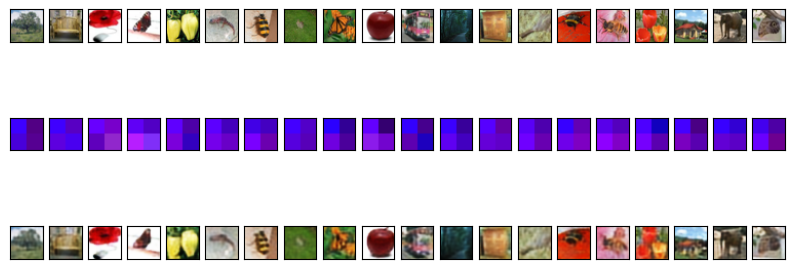

In [27]:
import torch.nn.functional as F

numero_imagens = 20
# Pega 20 imagens do batch 0
imagens_teste = (next(iter(loader_test))[0][:numero_imagens]).to(device)

model.eval()
with torch.no_grad():
    latente = model.encoder(imagens_teste)
    imagens_decodificadas = model.decoder(latente)
    imagens_codificadas = latente.reshape(latente.size(0), -1)

imagens_teste_plt = imagens_teste.detach().cpu().permute(0, 2, 3, 1).numpy()

# Latente (256, 2, 2) -> pega 3 canais e reescala para 16x16 RGB
latent_rgb = latente[:, :3, :, :].float().detach().cpu()
flat = latent_rgb.reshape(latent_rgb.size(0), -1)
min_v = flat.min(dim = 1).values.view(-1, 1, 1, 1)
max_v = flat.max(dim = 1).values.view(-1, 1, 1, 1)
latent_rgb = (latent_rgb - min_v) / (max_v - min_v + 1e-8)
latent_rgb = F.interpolate(latent_rgb, size = (16, 16), mode = 'nearest')
imagens_codificadas_plt = latent_rgb.permute(0, 2, 3, 1).numpy()

imagens_decodificadas_plt = imagens_decodificadas.detach().cpu().clamp(0, 1).permute(0, 2, 3, 1).numpy()

fig, axes = plt.subplots(nrows = 3, ncols = numero_imagens, figsize = (10, 4))
for imagens, ax_row in zip([imagens_teste_plt, imagens_codificadas_plt, imagens_decodificadas_plt], axes):
    for img, ax in zip(imagens, ax_row):
        ax.imshow(img.clip(0, 1))
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)